# Real-World Validation

In [ ]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

sys.path.insert(0, os.path.abspath("../scripts"))
from real_world_adapter import flatten_real_world

print("Imports loaded.")

Imports loaded.


In [ ]:
model    = joblib.load("../models/accessibility_model.joblib")
le       = joblib.load("../models/label_encoder.joblib")
metadata = joblib.load("../models/model_metadata.joblib")

print("Model type  :", type(model.named_steps["classifier"]).__name__)
print("Features    :", metadata["features"])
print("Classes     :", list(le.classes_))

Model type  : LogisticRegression
Features    : ['site_type', 'total_floors', 'step_free_entrance', 'handrails_present', 'elevator_present', 'total_services', 'avg_clear_signage', 'avg_high_contrast', 'accessible_service_ratio', 'upper_service_ratio', 'critical_upper_ratio', 'accessible_critical_ratio']
Classes     : ['high', 'low', 'medium']


In [ ]:
alu_rows = flatten_real_world("../data/real_world/ALU.json")
rmh_rows = flatten_real_world("../data/real_world/RMH.json")

df_real = pd.DataFrame(alu_rows + rmh_rows)
print(f"Total buildings: {len(df_real)}  (ALU={len(alu_rows)}, RMH={len(rmh_rows)})")
df_real.head()

Total buildings: 21  (ALU=3, RMH=18)


,building_id,building_name,site_type,total_floors,step_free_entrance,handrails_present,elevator_present,total_services,avg_clear_signage,avg_high_contrast,accessible_service_ratio,upper_service_ratio,critical_upper_ratio,accessible_critical_ratio,num_critical_services,num_services_ground,num_services_upper,num_critical_upper,expected_score,expected_class
0,SCHOOL_ALU_LC,Leadership Common,school,3,1,1,1,8,1.0,1.0,1.0,0.625,0.4,1.0,5,3,5,2,1.00,high
1,SCHOOL_ALU_SC,Social Common,school,3,1,1,1,4,1.0,1.0,1.0,0.750,0.0,0.0,0,1,3,0,0.80,high
2,SCHOOL_ALU_EC,Enterprise Common,school,3,1,1,1,3,1.0,1.0,1.0,0.333,0.0,0.0,0,2,1,0,0.80,high
3,Hospital_RMH_Rec,Reception,hospital,1,1,0,0,3,1.0,1.0,1.0,0.000,0.0,1.0,3,3,0,0,0.76,high
4,Hospital_RMH_Off,Offices,hospital,1,1,0,0,5,1.0,1.0,1.0,0.000,0.0,0.0,0,5,0,0,0.56,medium


In [ ]:
feature_cols = metadata["features"]

print("--- Expected (formula-based) class distribution ---")
print(df_real["expected_class"].value_counts())
print()

missing = set(feature_cols) - set(df_real.columns)
if missing:
    print(f"[!] Missing features: {missing}")
else:
    print("[OK] All model features present in real-world data.")

print()
df_real[["building_name", "site_type", "expected_score", "expected_class"]]

--- Expected (formula-based) class distribution ---
expected_class
high      15
medium     6
Name: count, dtype: int64

✅ All model features present in real-world data.



,building_name,site_type,expected_score,expected_class
0,Leadership Common,school,1.00,high
1,Social Common,school,0.80,high
2,Enterprise Common,school,0.80,high
3,Reception,hospital,0.76,high
4,Offices,hospital,0.56,medium
5,Ophthalmology,hospital,0.76,high
6,Accident Emergency,hospital,0.76,high
7,Dermatology Consultation,hospital,0.76,high
8,OPD Consultation,hospital,0.56,medium
9,Medical Emergency,hospital,0.76,high


In [ ]:
X_real = df_real[feature_cols]
y_pred_encoded = model.predict(X_real)
y_pred_labels  = le.inverse_transform(y_pred_encoded)

df_real["predicted_class"] = y_pred_labels
df_real["match"] = df_real["predicted_class"] == df_real["expected_class"]

df_real[["building_name", "site_type", "expected_score",
         "expected_class", "predicted_class", "match"]]

,building_name,site_type,expected_score,expected_class,predicted_class,match
0,Leadership Common,school,1.00,high,high,True
1,Social Common,school,0.80,high,high,True
2,Enterprise Common,school,0.80,high,high,True
3,Reception,hospital,0.76,high,high,True
4,Offices,hospital,0.56,medium,medium,True
5,Ophthalmology,hospital,0.76,high,high,True
6,Accident Emergency,hospital,0.76,high,high,True
7,Dermatology Consultation,hospital,0.76,high,high,True
8,OPD Consultation,hospital,0.56,medium,medium,True
9,Medical Emergency,hospital,0.76,high,high,True


In [ ]:
overall_match = df_real["match"].mean() * 100

print(f"Overall match rate: {overall_match:.1f}%  ({df_real['match'].sum()}/{len(df_real)})")
print()

for site in df_real["site_type"].unique():
    sub = df_real[df_real["site_type"] == site]
    rate = sub["match"].mean() * 100
    print(f"  {site:12s}  {rate:5.1f}%  ({sub['match'].sum()}/{len(sub)})")

Overall match rate: 100.0%  (21/21)

  school        100.0%  (3/3)
  hospital      100.0%  (18/18)


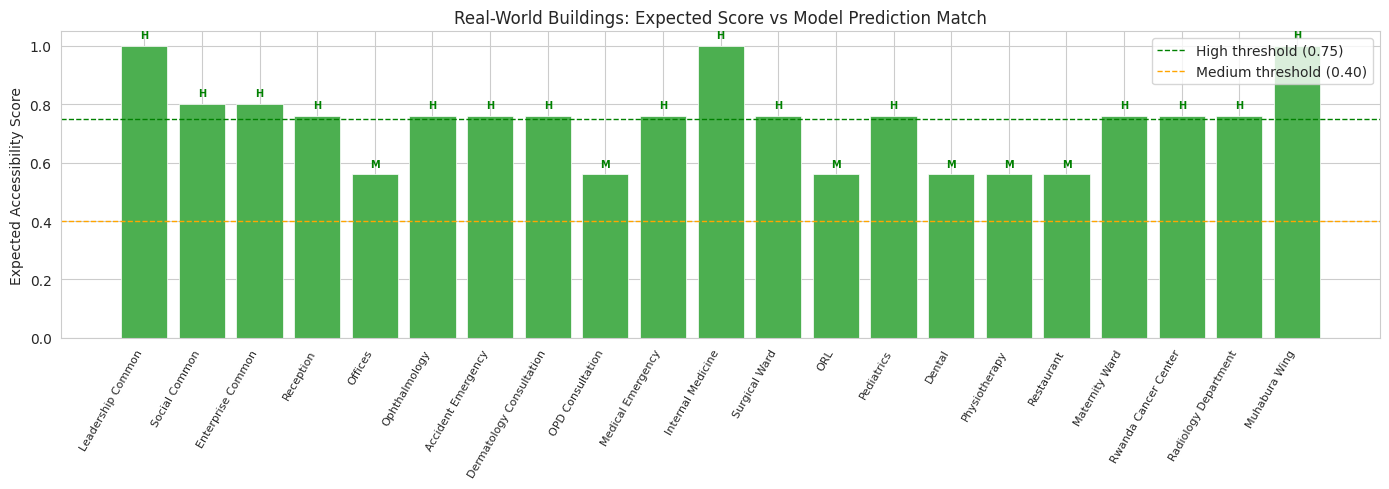

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(df_real))
bar_colors = df_real["match"].map({True: "#4CAF50", False: "#F44336"})

ax.bar(x, df_real["expected_score"], color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axhline(0.75, color="green",  linestyle="--", linewidth=1, label="High threshold (0.75)")
ax.axhline(0.40, color="orange", linestyle="--", linewidth=1, label="Medium threshold (0.40)")

ax.set_xticks(x)
ax.set_xticklabels(df_real["building_name"], rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Expected Accessibility Score")
ax.set_title("Real-World Buildings: Expected Score vs Model Prediction Match")
ax.legend(loc="upper right")

for i, row in df_real.iterrows():
    ax.text(i, row["expected_score"] + 0.02, row["predicted_class"][0].upper(),
            ha="center", va="bottom", fontsize=7, fontweight="bold",
            color="green" if row["match"] else "red")

plt.tight_layout()
plt.savefig("real_world_validation_chart.png", dpi=150)
plt.show()

In [ ]:
mismatches = df_real[~df_real["match"]].copy()

if mismatches.empty:
    print("No mismatches -- model predictions perfectly match expected classes!")
else:
    print(f"[!] {len(mismatches)} mismatch(es) found:\n")
    for _, row in mismatches.iterrows():
        print(f"  {row['building_name']} ({row['site_type']})")
        print(f"    Expected : {row['expected_class']}  (score={row['expected_score']:.3f})")
        print(f"    Predicted: {row['predicted_class']}")
        print(f"    Floors={row.get('total_floors', '?')}, "
              f"Elevator={row.get('elevator_present', '?')}, "
              f"AccessRatio={row.get('accessible_service_ratio', '?'):.2f}")
        print()

🎉 No mismatches — model predictions perfectly match expected classes!


## v2 Structural-Only Model Validation

In [ ]:
model_v2    = joblib.load("../models/accessibility_model_v2.joblib")
le_v2       = joblib.load("../models/label_encoder_v2.joblib")
metadata_v2 = joblib.load("../models/model_metadata_v2.joblib")

print("v2 Model type :", type(model_v2.named_steps["classifier"]).__name__)
print("v2 Features   :", metadata_v2["features"])
print(f"v2 Train acc  : {metadata_v2['test_accuracy']:.4f}")
print(f"v2 CV acc     : {metadata_v2['cv_accuracy_mean']:.4f}")

v2 Model type : LogisticRegression
v2 Features   : ['site_type', 'total_floors', 'total_services', 'num_critical_services', 'num_services_ground', 'num_services_upper', 'num_critical_upper', 'upper_service_ratio', 'critical_upper_ratio']
v2 Train acc  : 0.3725
v2 CV acc     : 0.3851


In [ ]:
feature_cols_v2 = metadata_v2["features"]

missing_v2 = set(feature_cols_v2) - set(df_real.columns)
if missing_v2:
    print(f"[!] Missing v2 features: {missing_v2}")
else:
    print("[OK] All v2 features present.")

X_real_v2 = df_real[feature_cols_v2]
y_pred_v2_enc = model_v2.predict(X_real_v2)
y_pred_v2_labels = le_v2.inverse_transform(y_pred_v2_enc)

df_real["predicted_class_v2"] = y_pred_v2_labels
df_real["match_v2"] = df_real["predicted_class_v2"] == df_real["expected_class"]

df_real[["building_name", "site_type", "expected_score",
         "expected_class", "predicted_class", "match",
         "predicted_class_v2", "match_v2"]]

✅ All v2 features present.


,building_name,site_type,expected_score,expected_class,predicted_class,match,predicted_class_v2,match_v2
0,Leadership Common,school,1.00,high,high,True,high,True
1,Social Common,school,0.80,high,high,True,medium,False
2,Enterprise Common,school,0.80,high,high,True,low,False
3,Reception,hospital,0.76,high,high,True,low,False
4,Offices,hospital,0.56,medium,medium,True,low,False
5,Ophthalmology,hospital,0.76,high,high,True,low,False
6,Accident Emergency,hospital,0.76,high,high,True,low,False
7,Dermatology Consultation,hospital,0.76,high,high,True,low,False
8,OPD Consultation,hospital,0.56,medium,medium,True,low,False
9,Medical Emergency,hospital,0.76,high,high,True,low,False


In [ ]:
v1_match = df_real["match"].mean() * 100
v2_match = df_real["match_v2"].mean() * 100

print("=" * 50)
print("         v1 (all features)  vs  v2 (structural)")
print("=" * 50)
print(f"Overall    {v1_match:5.1f}%              {v2_match:5.1f}%")

for site in df_real["site_type"].unique():
    sub = df_real[df_real["site_type"] == site]
    r1 = sub["match"].mean() * 100
    r2 = sub["match_v2"].mean() * 100
    print(f"  {site:10s} {r1:5.1f}%              {r2:5.1f}%")

print()
print(f"v2 mismatches: {(~df_real['match_v2']).sum()} / {len(df_real)}")

         v1 (all features)  vs  v2 (structural)
Overall    100.0%                9.5%
  school     100.0%               33.3%
  hospital   100.0%                5.6%

v2 mismatches: 19 / 21


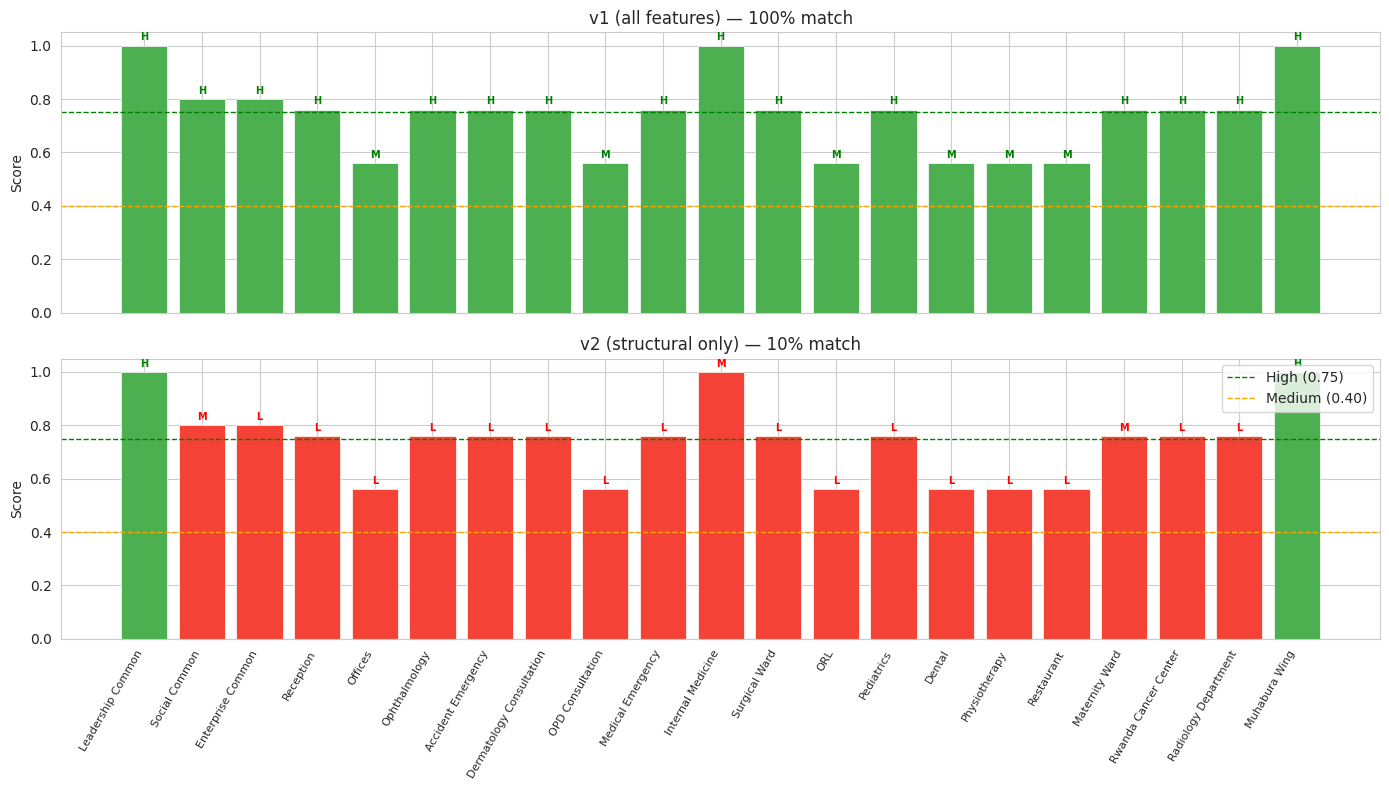

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x = np.arange(len(df_real))

colors_v1 = df_real["match"].map({True: "#4CAF50", False: "#F44336"})
ax1.bar(x, df_real["expected_score"], color=colors_v1, edgecolor="white", linewidth=0.5)
ax1.axhline(0.75, color="green", linestyle="--", linewidth=1)
ax1.axhline(0.40, color="orange", linestyle="--", linewidth=1)
ax1.set_ylabel("Score")
ax1.set_title(f"v1 (all features) -- {v1_match:.0f}% match")
for i, row in df_real.iterrows():
    ax1.text(i, row["expected_score"] + 0.02, row["predicted_class"][0].upper(),
             ha="center", fontsize=7, fontweight="bold",
             color="green" if row["match"] else "red")

colors_v2 = df_real["match_v2"].map({True: "#4CAF50", False: "#F44336"})
ax2.bar(x, df_real["expected_score"], color=colors_v2, edgecolor="white", linewidth=0.5)
ax2.axhline(0.75, color="green", linestyle="--", linewidth=1, label="High (0.75)")
ax2.axhline(0.40, color="orange", linestyle="--", linewidth=1, label="Medium (0.40)")
ax2.set_ylabel("Score")
ax2.set_title(f"v2 (structural only) -- {v2_match:.0f}% match")
ax2.legend(loc="upper right")

ax2.set_xticks(x)
ax2.set_xticklabels(df_real["building_name"], rotation=60, ha="right", fontsize=8)
for i, row in df_real.iterrows():
    ax2.text(i, row["expected_score"] + 0.02, row["predicted_class_v2"][0].upper(),
             ha="center", fontsize=7, fontweight="bold",
             color="green" if row["match_v2"] else "red")

plt.tight_layout()
plt.savefig("real_world_validation_v1_vs_v2.png", dpi=150)
plt.show()

## v1 vs v2 Conclusion

| Model | Training Accuracy | CV Accuracy | Real-World Match |
|---|---|---|---|
| **v1** (all features) | 99.0% | 98.2% | **100%** (21/21) |
| **v2** (structural only) | 37.3% | 38.5% | **9.5%** (2/21) |

### Key Takeaway

The v1 model's near-perfect accuracy was entirely driven by **formula leakage** -- the features it used are the literal inputs to the deterministic scoring formula. When those features are removed (v2), accuracy drops to ~38% on synthetic data and **9.5%** on real-world data -- worse than random chance.

### What This Means

1. **Structural features alone** (floors, service counts, spatial distribution) carry **no meaningful signal** for predicting formula-based accessibility class. This is expected -- the formula weights *how* services are delivered (ramps, elevators, signage), not *what* exists structurally.

2. **The v1 model is the right choice for production** -- it reliably replicates the scoring formula with 100% real-world match. The "leakage" is actually a feature, not a bug: the model efficiently approximates the formula.

3. **To go beyond formula replication**, the project needs **real human-labelled accessibility assessments** as ground truth instead of formula-computed labels.